In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned/superstore_cleaned.csv")

In [2]:
# KPI's
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

Total Sales: 12642905
Total Profit: 1467457.2912800002
Total Orders: 25035
Total Customers: 4873


*💡 Insight*
“The business generated 12642905 total sales with 1467457.29 profit”
“Average revenue per customer = …”

Time Series Analysis

🔹 Monthly Sales Trend

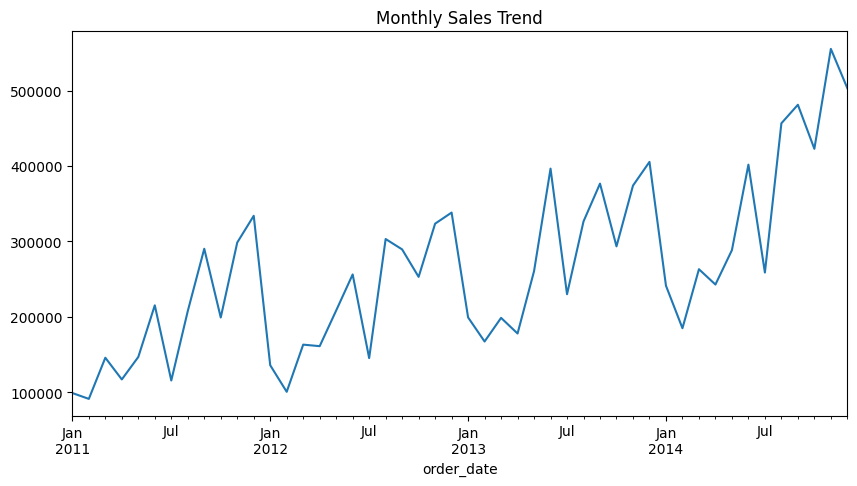

In [3]:
df['order_date'] = pd.to_datetime(df['order_date'])

monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()

monthly_sales.plot(figsize=(10,5), title="Monthly Sales Trend")
plt.show()

🔹 Monthly Profit Trend

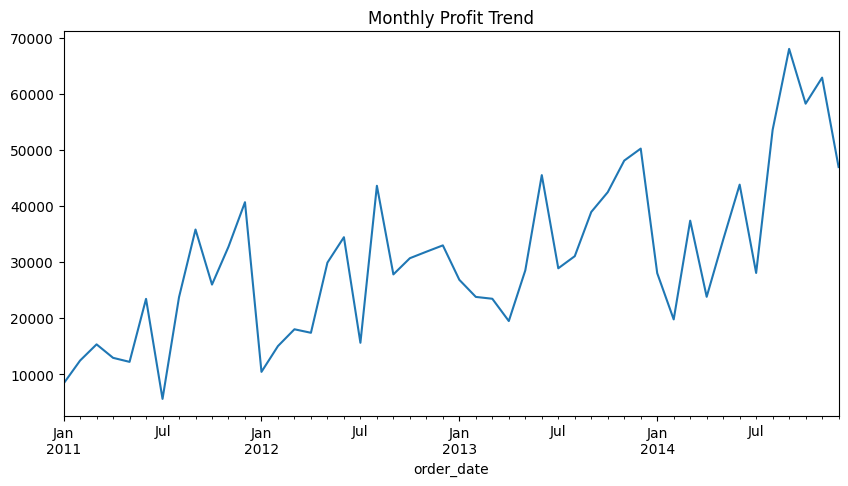

In [4]:
monthly_profit = df.groupby(df['order_date'].dt.to_period('M'))['profit'].sum()

monthly_profit.plot(figsize=(10,5), title="Monthly Profit Trend")
plt.show()

*💡 Insight*

Geographic Analysis

🔹 Sales by Country

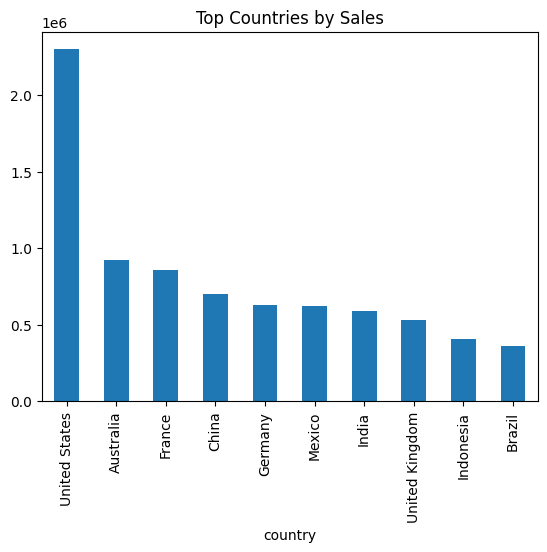

In [5]:
country_sales = df.groupby('country')['sales'].sum().sort_values(ascending=False)

country_sales.head(10).plot(kind='bar', title="Top Countries by Sales")
plt.show()

🔹 Profit by Region

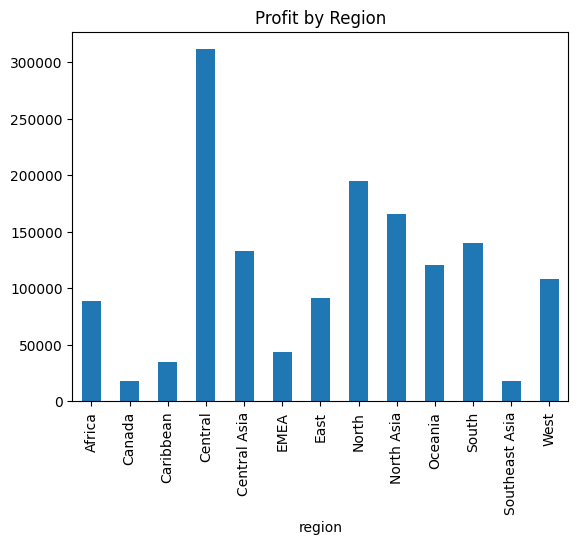

In [6]:
region_profit = df.groupby('region')['profit'].sum()

region_profit.plot(kind='bar', title="Profit by Region")
plt.show()

*Insight*

Product & Category Analysis

🔹 Sales by Category

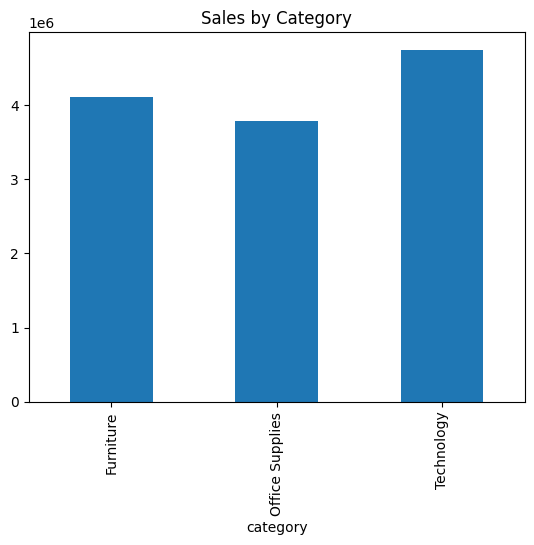

In [7]:
category_sales = df.groupby('category')['sales'].sum()

category_sales.plot(kind='bar', title="Sales by Category")
plt.show()

🔹 Profit by Category

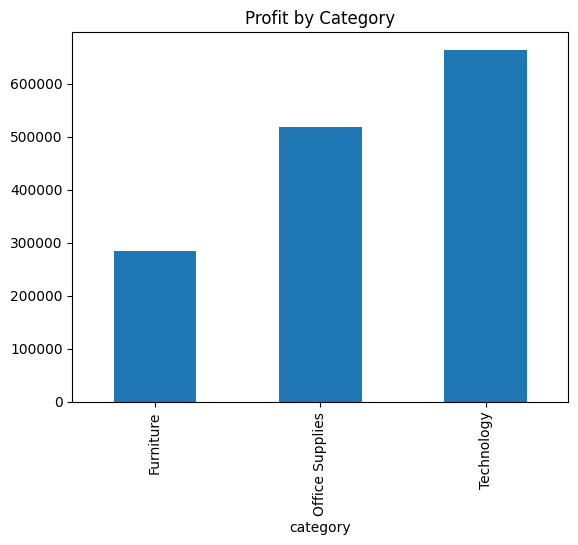

In [8]:
category_profit = df.groupby('category')['profit'].sum()

category_profit.plot(kind='bar', title="Profit by Category")
plt.show()

🔹 Sub-category Analysis

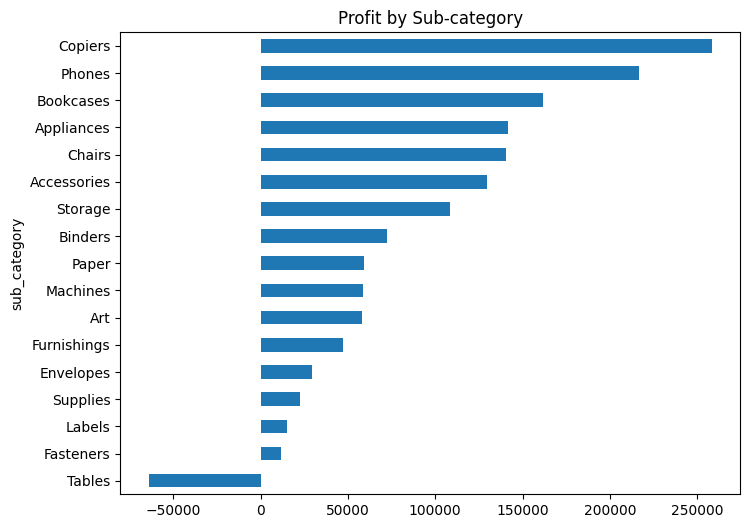

In [9]:
subcat_profit = df.groupby('sub_category')['profit'].sum().sort_values()

subcat_profit.plot(kind='barh', figsize=(8,6), title="Profit by Sub-category")
plt.show()

*Insight*

🔹 Find loss-making transactions

In [10]:
loss_df = df[df['profit'] < 0]

loss_df.head()

,category,city,country,customer_id,customer_name,discount,market,order_date,order_id,order_priority,...,segment,ship_date,ship_mode,shipping_cost,state,sub_category,order_year,order_month,order_day,month_name
29009,Technology,Paris,France,RC-198252,Roy Collins,0.15,EU,2011-04-26,IT-2011-2185983,Critical,...,Consumer,2011-04-27,Same Day,100.32,Ile-de-France,Phones,2011,4,26,April
29012,Technology,Taverny,France,TB-211752,Thomas Boland,0.15,EU,2011-08-26,ES-2011-5235241,High,...,Corporate,2011-08-27,Same Day,70.11,Ile-de-France,Copiers,2011,8,26,August
29018,Technology,Tremblay-en-France,France,DH-130752,Dave Hallsten,0.15,EU,2011-12-02,ES-2011-4614329,High,...,Corporate,2011-12-04,First Class,5.53,Ile-de-France,Machines,2011,12,2,December
29021,Technology,Guyancourt,France,MH-174552,Mark Hamilton,0.15,EU,2012-06-07,ES-2012-2141914,High,...,Consumer,2012-06-11,Second Class,60.78,Ile-de-France,Phones,2012,6,7,June
29024,Technology,Le Plessis-Robinson,France,AA-104802,Andrew Allen,0.15,EU,2012-08-30,IT-2012-5602177,Medium,...,Consumer,2012-09-02,Second Class,111.55,Ile-de-France,Copiers,2012,8,30,August


🔹 Top loss categories

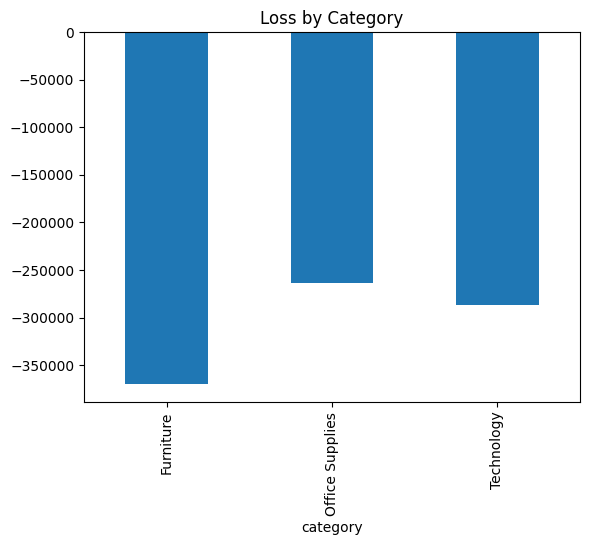

In [11]:
loss_category = loss_df.groupby('category')['profit'].sum()

loss_category.plot(kind='bar', title="Loss by Category")
plt.show()

*🧠 Insight*

Customer Analysis

🔹 Top Customers

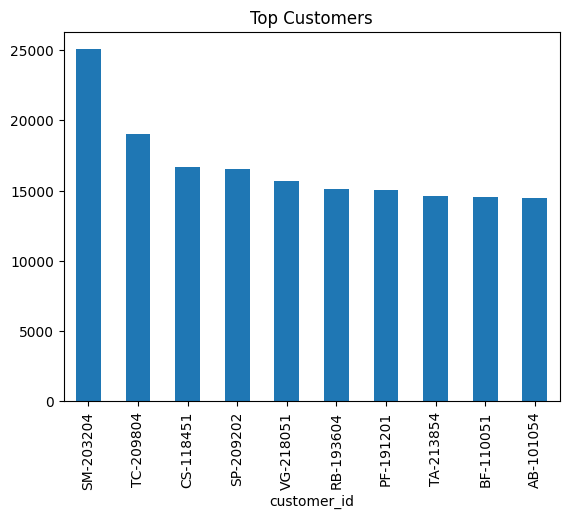

In [12]:
top_customers = df.groupby('customer_id')['sales'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar', title="Top Customers")
plt.show()

🔹 Orders per Customer

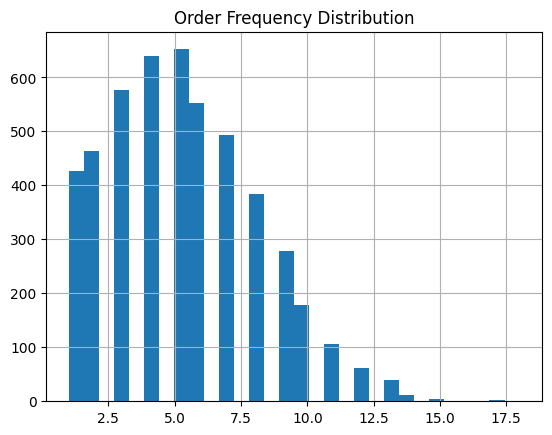

In [13]:
orders_per_customer = df.groupby('customer_id')['order_id'].nunique()

orders_per_customer.hist(bins=30)
plt.title("Order Frequency Distribution")
plt.show()

🧠 Insight

Profitability Analysis

🔹 Profit Margin

In [14]:
df['profit_margin'] = df['profit'] / df['sales']

🔹 Average margin by category

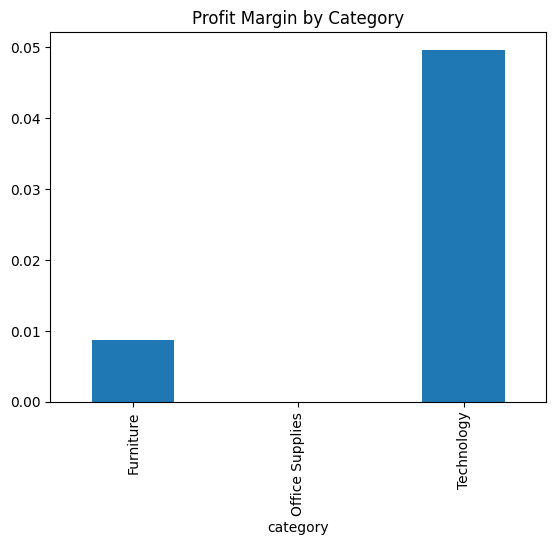

In [15]:
margin_category = df.groupby('category')['profit_margin'].mean()

margin_category.plot(kind='bar', title="Profit Margin by Category")
plt.show()

*🧠 Insight*

Segment Analysis

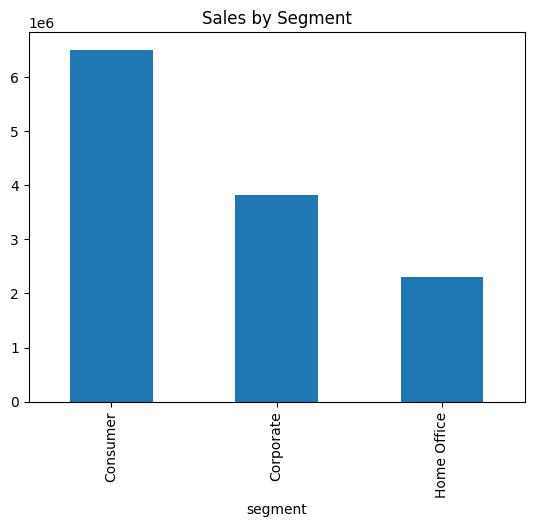

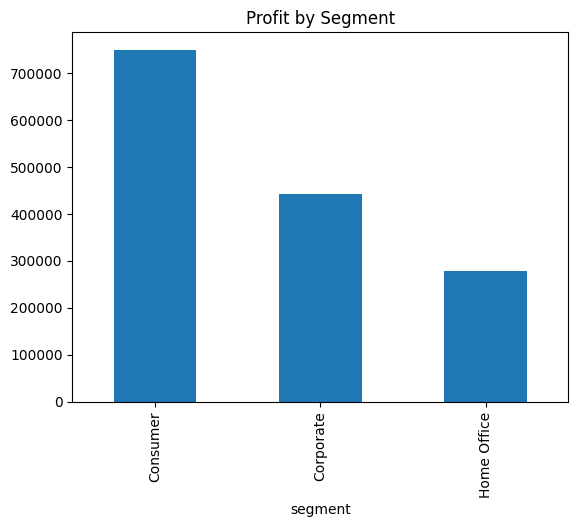

In [16]:
segment_sales = df.groupby('segment')['sales'].sum()
segment_profit = df.groupby('segment')['profit'].sum()

segment_sales.plot(kind='bar', title="Sales by Segment")
plt.show()

segment_profit.plot(kind='bar', title="Profit by Segment")
plt.show()

*🧠 Insight*